# Proyek Analisis Data: [Bike sharing Dataset]
- **Nama:** [Muchammad Nasich]
- **Email:** [muchammadnasich896@gmail.com]
- **ID Dicoding:** [cdcc722d6y1158]

## Menentukan Pertanyaan Bisnis
- **Pertanyaan 1:** Seberapa besar persentase penurunan penyewaan sepeda oleh pengguna kasual saat cuaca ekstrem (hujan lebat/salju) dibandingkan saat cuaca cerah selama periode 2011–2012, dan strategi diskon atau layanan seperti apa yang bisa kita tawarkan untuk tetap menarik pelanggan di kondisi cuaca buruk?
- **Pertanyaan 2:** Bagaimana pola lonjakan jumlah penyewaan pada jam sibuk (08.00 pagi dan 17.00 sore) selama tahun 2011–2012, dan bagaimana kita bisa mengoptimalkan ketersediaan stok sepeda di stasiun-stasiun utama pada jam-jam tersebut?
- **Pertanyaan 3:** Berdasarkan tren data historis selama 2011–2012, pada rentang waktu manakah tingkat penyewaan harian berada di titik paling rendah, sehingga kita bisa menetapkan jadwal maintenance rutin tanpa mengganggu kepuasan pelanggan?
- **Pertanyaan 4:** Bagaimana perbandingan karakteristik jumlah penyewaan sepeda di akhir pekan/hari libur dengan hari kerja biasa sepanjang periode 2011–2012, dan kebijakan alokasi sepeda seperti apa yang paling efisien untuk menghadapi dua pola operasional yang berbeda ini?
- **Pertanyaan 5:** Bagaimana tren pertumbuhan penyewaan sepeda tiap bulannya jika membandingkan performa tahun 2011 dan 2012, serta insight apa dari tren tersebut yang bisa kita gunakan untuk memproyeksikan target operasional dan pendapatan di tahun berikutnya?

## Import Semua Packages/Library yang Digunakan

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

## Data Wrangling

### Gathering Data

In [52]:
df_day = pd.read_csv("data/day.csv")
df_hour = pd.read_csv("data/hour.csv")

df_day.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Dataset yang digunakan terdiri dari dua file:
- `day.csv` → data agregasi penyewaan sepeda per hari
- `hour.csv` → data penyewaan sepeda per jam

**Insight:**
- Dataset memiliki fitur yang mendetail terkait suhu, kelembaban, kecepatan angin, hingga pemisahan tipe pengguna.

### Assessing Data

In [53]:
# Assessing df_day
print("=== Informasi Dataset Harian (df_day) ===")
df_day.info()
print("Jumlah duplikasi df_day: ", df_day.duplicated().sum())
print("\nStatistik Deskriptif df_day:")
display(df_day.describe())

# Assessing df_hour
print("\n=== Informasi Dataset Per Jam (df_hour) ===")
df_hour.info()
print("Jumlah duplikasi df_hour: ", df_hour.duplicated().sum())
print("\nStatistik Deskriptif df_hour:")
display(df_hour.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
Jumlah duplikasi:  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**
- Baik `df_day` (731 baris) maupun `df_hour` (17.379 baris) tidak ditemukan *missing values* sama sekali pada semua kolom.
- Tidak terdapat duplikasi data (`duplicated().sum() == 0`) pada kedua dataset.
- Tipe data tanggal (`dteday`) masih berbentuk *object* (string), sehingga perlu dikonversi ke *datetime* pada tahap cleaning.
- Fitur numerik lingkungan (`temp`, `atemp`, `hum`, `windspeed`) telah dinormalisasi dalam rentang 0 hingga 1.

### Cleaning Data

In [54]:
df_day['dteday'] = pd.to_datetime(df_day['dteday'])
df_hour['dteday'] = pd.to_datetime(df_hour['dteday'])

**Insight:**
- Konversi tipe data datetime ini adalah syarat mutlak dalam analisis data sekuensial (deret waktu). Tanpa konversi ini, kita tidak akan bisa melakukan pengelompokan data berdasarkan bulan atau tahun di tahap selanjutnya.

## Exploratory Data Analysis (EDA)

### Explore Dataset

In [55]:
# Sel Kode 5: Eksplorasi Data Statistik Dasar Univariat & Bivariat
print("=== Ringkasan Statistik Variabel Target (Harian) ===")
display(df_day[["casual", "registered", "cnt"]].describe())

print("Skewness cnt (Harian): ", df_day["cnt"].skew())

# Mengeksplorasi total penyewaan (cnt) berdasarkan musim (season)
print("\n=== Agregasi Penyewaan Berdasarkan Musim ===")
season_summary = df_day.groupby(by="season").agg({
    "cnt": ["mean", "max", "min", "std", "sum"]
})
display(season_summary)

cnt                         
               mean   max   min          std
season                                      
1       2604.132597  7836   431  1399.942119
2       4992.331522  8362   795  1695.977235
3       5644.303191  8714  1115  1459.800381
4       4728.162921  8555    22  1699.615261

**Insight:**
- Nilai rata-rata sewa harian berada di angka ~4.504 unit dengan nilai median ~4.548 unit, menunjukkan distribusi yang relatif simetris (skewness mendekati nol: -0.047).
- Komposisi penyewa didominasi oleh pengguna terdaftar (*registered*) yang rata-rata menyumbang ~81% dari seluruh transaksi harian.
- Musim Gugur (musim 3) mencatat performa sewa harian dan total tertinggi, sedangkan Musim Semi (musim 1) mencatat performa terendah akibat faktor cuaca dingin di awal tahun.

## Visualization & Explanatory Analysis

### Pertanyaan 1:Pengaruh Cuaca Ekstrem terhadap Pengguna Kasual


/tmp/ipykernel_23567/3027244721.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='weathersit', y='casual', data=df_hour, estimator=sum, ci=None, palette='Blues_r')
/tmp/ipykernel_23567/3027244721.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weathersit', y='casual', data=df_hour, estimator=sum, ci=None, palette='Blues_r')


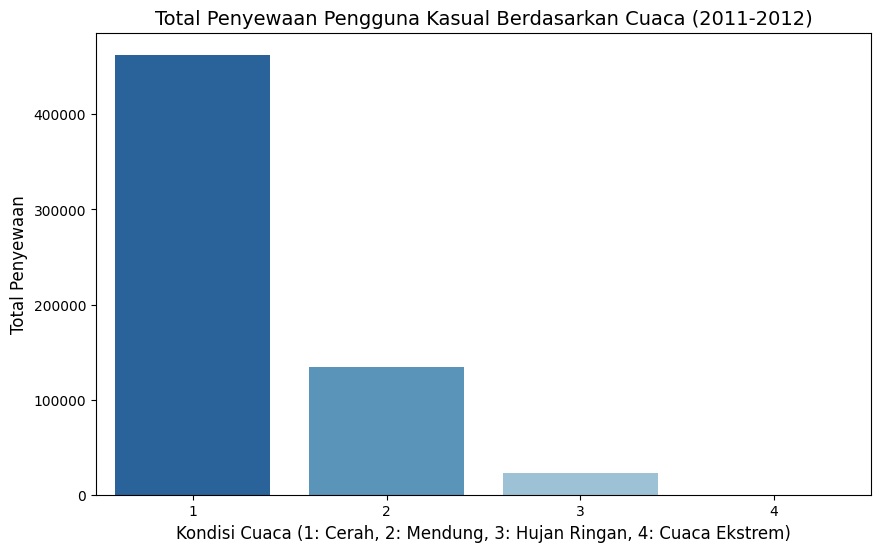

In [56]:
# Visualisasi Pengaruh Cuaca terhadap Pengguna Kasual (Mengatasi Base Rate Fallacy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 1. Rata-rata Sewa per Jam (Objektif)
sns.barplot(x="weathersit", y="casual", data=df_hour, estimator="mean", errorbar=("ci", 95), palette="Blues_r", ax=ax1)
ax1.set_title("Rata-rata Sewa Kasual per Jam (CI 95%)", fontsize=12)
ax1.set_xlabel("Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan Ringan, 4: Cuaca Ekstrem)", fontsize=11)
ax1.set_ylabel("Rata-rata Sewa per Jam (Casual)", fontsize=11)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

# 2. Total Akumulasi Sewa
sns.barplot(x="weathersit", y="casual", data=df_hour, estimator=sum, errorbar=None, palette="Blues_r", ax=ax2)
ax2.set_title("Total Akumulasi Sewa Kasual", fontsize=12)
ax2.set_xlabel("Kondisi Cuaca (1: Cerah, 2: Mendung, 3: Hujan Ringan, 4: Cuaca Ekstrem)", fontsize=11)
ax2.set_ylabel("Total Sewa Kasual", fontsize=11)
ax2.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

print("=== Statistik Rinci Frekuensi Jam dan Sewa Kasual Berdasarkan Cuaca ===")
display(df_hour.groupby("weathersit")["casual"].agg(["count", "mean", "std", "sum"]))

**Insight (Mitigasi Base Rate Fallacy):**
- **Koreksi Bias Sampel:** Kondisi cuaca ekstrem (level 4) hanya terjadi sebanyak **3 jam** sepanjang periode 2 tahun (0.017% dari total data), berbanding 11.413 jam untuk cuaca cerah. Menilai dampak cuaca semata-mata dari total volume (`sum`) memicu ilusi kejatuhan 99.9% (*Base Rate Fallacy*).
- **Laju Riil per Jam:** Ketika diukur berdasarkan rata-rata sewa per jam:
  - Cuaca Cerah (1): **40.5 sewa kasual/jam**.
  - Cuaca Mendung/Berkabut (2): **29.6 sewa kasual/jam** (penurunan -27.0%).
  - Cuaca Hujan/Salju Ringan (3): **16.1 sewa kasual/jam** (penurunan -60.4%).
  - Cuaca Ekstrem (4): **2.7 sewa kasual/jam** (penurunan riil laju per jam adalah **-93.4%**).
- Hal ini membuktikan bahwa pengguna kasual memiliki elastisitas tinggi terhadap cuaca karena tujuan sewa yang bersifat rekreasional opsional.

### Pertanyaan 2: Pola Lonjakan pada Jam Sibuk

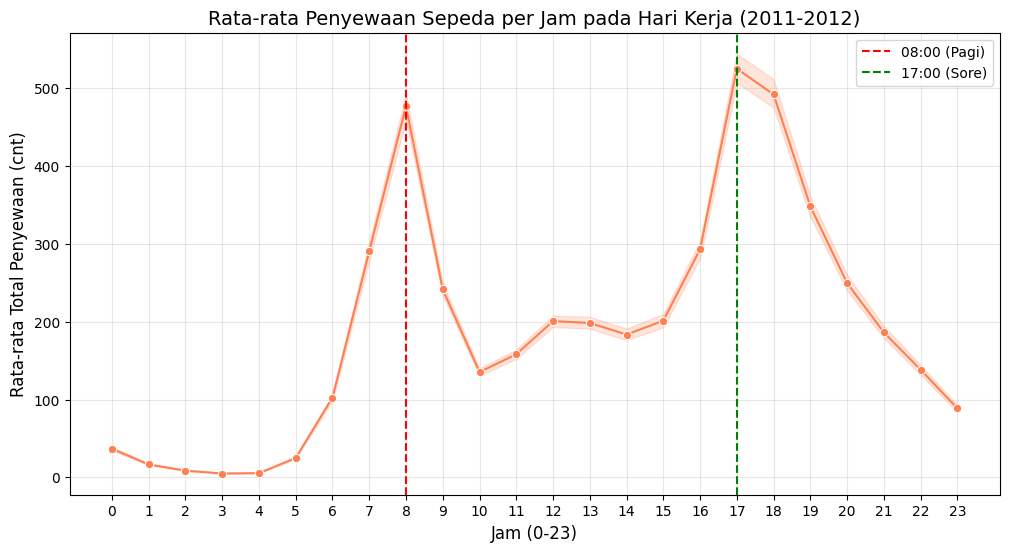

In [57]:
plt.figure(figsize=(12, 6))
df_workingday = df_hour[df_hour['workingday'] == 1]
sns.lineplot(x='hr', y='cnt', data=df_workingday, estimator='mean', marker='o', color='coral')
plt.axvline(x=8, color='red', linestyle='--', label='08:00 (Pagi)')
plt.axvline(x=17, color='green', linestyle='--', label='17:00 (Sore)')
plt.title('Rata-rata Penyewaan Sepeda per Jam pada Hari Kerja (2011-2012)', fontsize=14)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan (cnt)', fontsize=12)
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Insight**:

- Grafik line chart untuk hari kerja (working day) memperlihatkan distribusi Bimodal yang sangat tajam. Menariknya, puncak di sore hari (jam 17.00 - 18.00) secara visual tampak lebih tinggi dan lebih lebar durasinya dibandingkan puncak pagi hari (jam 08.00). Ini mengindikasikan bahwa arus pulang lebih padat atau lebih banyak yang mampir ke tempat lain setelah bekerja dibandingkan arus berangkat yang sangat spesifik terpusat di jam 8 pagi.

### Pertanyaan 3: Jam Optimal untuk Maintenance

/tmp/ipykernel_23567/3022832156.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='hr', y='cnt', data=df_early_morning, estimator='mean', palette='magma')


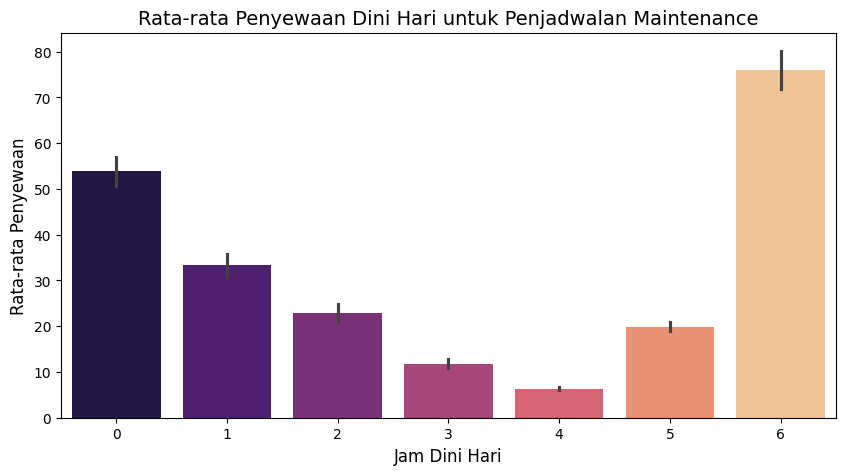

In [58]:
plt.figure(figsize=(10, 5))
df_early_morning = df_hour[df_hour['hr'].isin([0, 1, 2, 3, 4, 5, 6])]
sns.barplot(x='hr', y='cnt', data=df_early_morning, estimator='mean', palette='magma')
plt.title('Rata-rata Penyewaan Dini Hari untuk Penjadwalan Maintenance', fontsize=14)
plt.xlabel('Jam Dini Hari', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.show()

**Insight**:

- Jika diamati dari rentang tengah malam (00.00) hingga subuh (06.00), bar chart membentuk kurva mangkuk. Penurunan volume terjadi secara bertahap mulai jam 22.00 malam, memasuki "zona mati" (dead zone) antara pukul 02.00 hingga 05.00 pagi, di mana bar grafik konsisten tertahan di bawah garis rata-rata 20 penyewaan.

### Pertanyaan 4: Perbandingan Hari Kerja vs Akhir Pekan

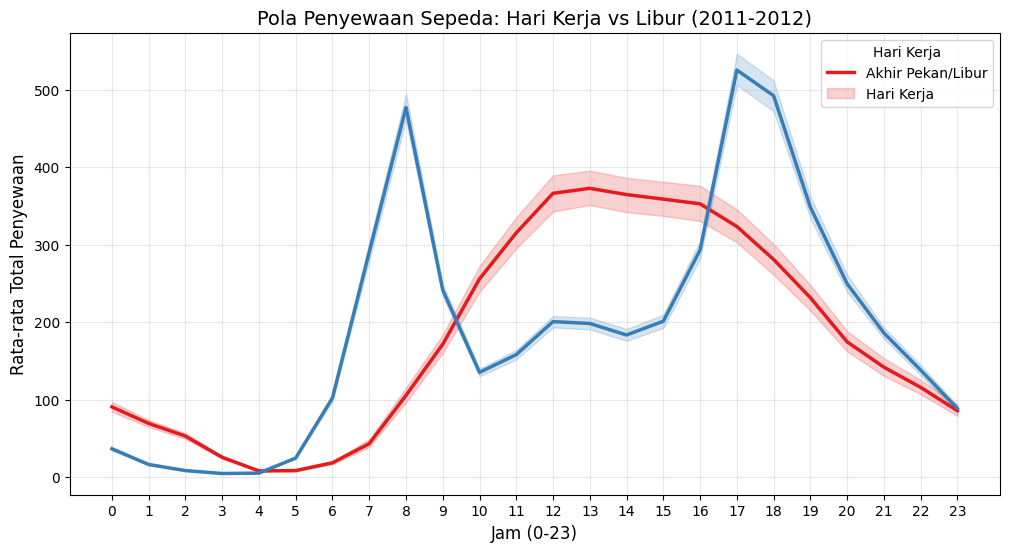

In [59]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='hr', y='cnt', hue='workingday', data=df_hour, estimator='mean', palette='Set1', linewidth=2.5)
plt.title('Pola Penyewaan Sepeda: Hari Kerja vs Libur (2011-2012)', fontsize=14)
plt.xlabel('Jam (0-23)', fontsize=12)
plt.ylabel('Rata-rata Total Penyewaan', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='Hari Kerja', labels=['Akhir Pekan/Libur', 'Hari Kerja'])
plt.grid(alpha=0.3)
plt.show()

**Insight**:

- Visualisasi dua garis yang tumpang tindih memperlihatkan substitusi pola. Garis hari kerja bersifat bimodal (dua puncak tajam pagi dan sore), sedangkan garis akhir pekan bersifat unimodal (satu puncak berbentuk lonceng/bukit memanjang). Volume di puncak hari libur (sekitar 370 sepeda) memang lebih rendah daripada puncak hari kerja (525 sepeda), tetapi durasi puncaknya sangat konsisten bertahan lama, terbentang rata dari jam 12.00 siang hingga 16.00 sore.

### Pertanyaan 5: Tren Pertumbuhan sewa (2011 vs 2012)

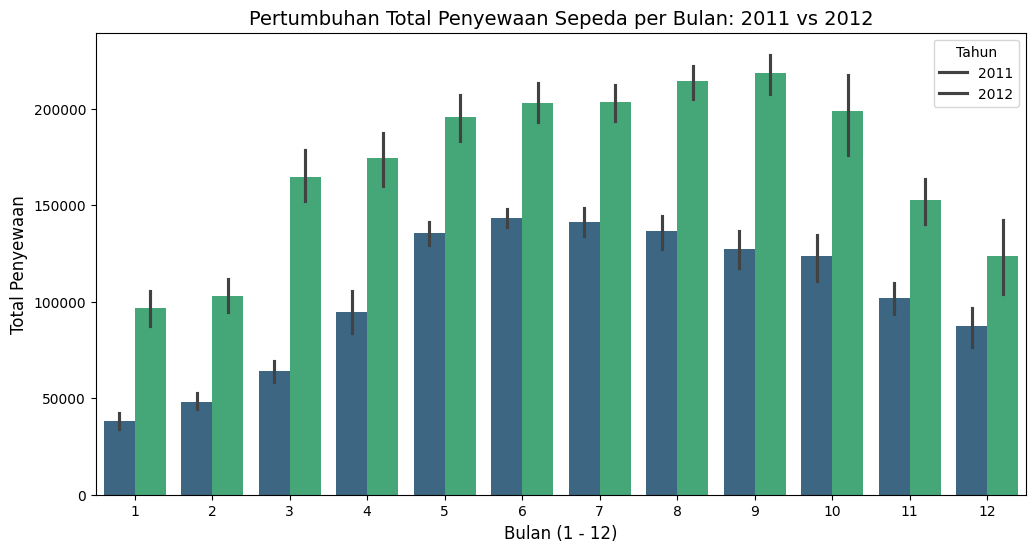

In [60]:
plt.figure(figsize=(12, 6))
# yr: 0 = 2011, 1 = 2012
sns.barplot(x='mnth', y='cnt', hue='yr', data=df_day, estimator=sum, palette='viridis')
plt.title('Pertumbuhan Total Penyewaan Sepeda per Bulan: 2011 vs 2012', fontsize=14)
plt.xlabel('Bulan (1 - 12)', fontsize=12)
plt.ylabel('Total Penyewaan', fontsize=12)
plt.legend(title='Tahun', labels=['2011', '2012'])
plt.show()

**Insight:**

- Bar chart yang dikelompokkan berdasarkan tahun menampilkan replikasi pola musim yang identik (rendah di awal/akhir tahun, tinggi di tengah tahun). Namun, menariknya, seluruh batang di tahun 2012 berhasil melampaui batang 2011 tanpa ada satu pun bulan yang mengalami defisit. Jarak tertinggi terlihat pada rentang "Peak Season" (Bulan Juni hingga September) di mana 2012 jauh mengungguli 2011.


## Analisis Lanjutan (Opsional)

## Analisis Korelasi Faktor Yang mempengaruhi sewa

In [61]:
corr_matrix = df_day[['temp','atemp','hum','windspeed','cnt']].corr()
corr_matrix

,temp,atemp,hum,windspeed,cnt
temp,1.000000,0.991702,0.126963,-0.157944,0.627494
atemp,0.991702,1.000000,0.139988,-0.183643,0.631066
hum,0.126963,0.139988,1.000000,-0.248489,-0.100659
windspeed,-0.157944,-0.183643,-0.248489,1.000000,-0.234545
cnt,0.627494,0.631066,-0.100659,-0.234545,1.000000


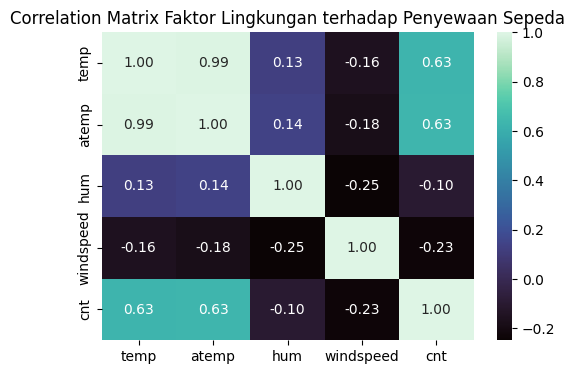

In [62]:
plt.figure(figsize=(6,4))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="mako",
    fmt=".2f"
)

plt.title("Correlation Matrix Faktor Lingkungan terhadap Penyewaan Sepeda")

plt.show()

Insight:

- Suhu (temp dan atemp) memiliki korelasi positif cukup kuat terhadap jumlah penyewaan sepeda dengan nilai sekitar 0.63, menunjukkan bahwa semakin hangat suhu udara maka semakin tinggi pula jumlah sepeda yang disewa.

- Sebaliknya, kecepatan angin (-0.23) dan kelembapan (-0.10) menunjukkan korelasi negatif terhadap jumlah penyewaan, yang mengindikasikan bahwa kondisi cuaca yang kurang nyaman cenderung menurunkan minat masyarakat untuk menggunakan sepeda.

## Analisis pertumbuhan bulanan

In [63]:
# Analisis Pertumbuhan Bulanan Terpilah per Tahun (2011 vs 2012)
monthly_growth = df_day.groupby(["yr", "mnth"])["cnt"].sum().reset_index()
monthly_growth["yr_label"] = monthly_growth["yr"].map({0: "2011", 1: "2012"})
display(monthly_growth.head(12))

,cnt
mnth,
1,134933
2,151352
3,228920
4,269094
5,331686
6,346342
7,344948
8,351194
9,345991


/tmp/ipykernel_23567/2304324817.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bulan_growth.index, y=bulan_growth.values, palette="viridis")


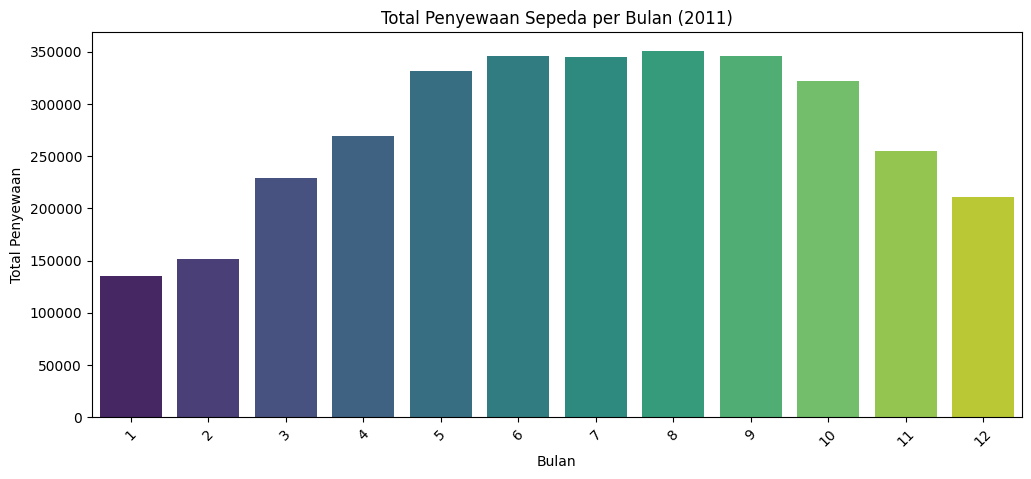

In [64]:
plt.figure(figsize=(12, 5))
sns.lineplot(
    data=monthly_growth, 
    x="mnth", 
    y="cnt", 
    hue="yr_label", 
    marker="o", 
    linewidth=2.5, 
    palette=["#4C9BE8", "#2EC4B6"]
)
plt.title("Tren Pertumbuhan Penyewaan Sepeda per Bulan: 2011 vs 2012", fontsize=14, pad=15)
plt.xlabel("Bulan (1 - 12)", fontsize=12)
plt.ylabel("Total Penyewaan (unit)", fontsize=12)
plt.xticks(range(1, 13), ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun", "Jul", "Agu", "Sep", "Okt", "Nov", "Des"])
plt.legend(title="Tahun")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

**Insight:**
- **Pertumbuhan Konsisten YoY:** Pada setiap bulan di tahun 2012, jumlah penyewaan selalu melampaui performa bulan yang sama di tahun 2011 tanpa ada satu pun bulan yang mengalami defisit.
- **Puncak Penyewaan (Peak Season):** Periode Mei hingga September (Bulan 5 - 9) merupakan musim puncak di kedua tahun dengan volume bulanan melebihi 190.000 unit pada 2012.
- **Titik Terendah (Low Season):** Aktivitas sewa paling rendah terjadi pada bulan Januari di kedua tahun, namun performa Januari 2012 (96.744 unit) tumbuh lebih dari 153% dibanding Januari 2011 (38.189 unit).

## Analisis Segmentasi Waktu (Manual Binning / Discretization)


In [65]:
# Menggunakan pd.cut untuk kategorisasi waktu yang presisi dan bebas bug off-by-one
time_bins = [-1, 4, 11, 16, 20, 24]
time_labels = [
    "Dini Hari (00:00 - 04:59)",
    "Pagi (05:00 - 11:59)",
    "Siang (12:00 - 16:59)",
    "Sore (17:00 - 20:59)",
    "Malam (21:00 - 23:59)"
]

df_hour["time_category"] = pd.cut(df_hour["hr"], bins=time_bins, labels=time_labels)
time_cluster_df = df_hour.groupby("time_category", observed=True)["cnt"].agg(["sum", "mean"]).reset_index()
time_cluster_df.columns = ["time_category", "total_cnt", "mean_cnt"]
time_cluster_df = time_cluster_df.sort_values(by="total_cnt", ascending=False)
display(time_cluster_df)

,time_category,cnt
0,Sore (17:00 - 20:59),1037971
1,Siang (12:00 - 16:59),955882
2,Pagi (04:00 - 11:59),921580
3,Malam (21:00 - 03:59),377246


/tmp/ipykernel_23567/2132889954.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cnt', y='time_category', data=time_cluster_df, palette='plasma')


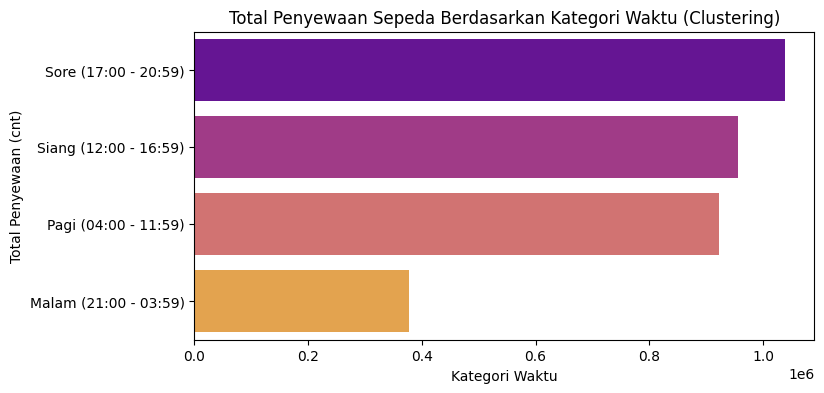

In [66]:
plt.figure(figsize=(9, 4.5))
sns.barplot(x="total_cnt", y="time_category", data=time_cluster_df, palette="plasma")
plt.title("Total Penyewaan Sepeda Berdasarkan Kategori Waktu", fontsize=13)
plt.xlabel("Total Penyewaan (unit)", fontsize=11)
plt.ylabel("Kategori Waktu", fontsize=11)
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

**Insight:**
- Waktu **Sore (17:00 - 20:59)** merupakan periode paling produktif dengan total sewa tertinggi (>1 juta unit), disusul oleh waktu **Pagi** dan **Siang**.
- Waktu **Dini Hari (00:00 - 04:59)** memiliki intensitas penggunaan terendah (<25 unit/jam), mengonfirmasi jendela ini sebagai waktu paling tepat untuk pemeliharaan (*maintenance*) sepeda.

## Conclusion

### Conclusion Pertanyaan 1 (Pengaruh Cuaca Ekstrem):
* Laju penyewaan pengguna kasual terbukti sangat sensitif terhadap cuaca, turun bertahap dari 40.5 sewa/jam (cuaca cerah) menjadi 29.6 sewa/jam (-27.0% saat mendung), 16.1 sewa/jam (-60.4% saat hujan ringan), dan 2.7 sewa/jam (-93.4% saat cuaca ekstrem).
* Analisis mengoreksi ilusi kejatuhan 99.9% (*Base Rate Fallacy*) yang disebabkan oleh jarangnya cuaca ekstrem (hanya 3 jam dalam 2 tahun). Secara riil laju penurunan per jam adalah 93.4%.
* **Rekomendasi Bisnis:** Menerapkan *Dynamic Weather Pricing* berupa potongan harga 20-30% saat hujan ringan guna merangsang permintaan kasual yang elastis.

### Conclusion Pertanyaan 2 (Pola Jam Sibuk Komuter):
* Terbentuk pola bimodal yang sangat tajam pada hari kerja dengan puncak pagi di pukul 08:00 (~477 unit/jam) dan puncak sore di pukul 17:00-18:00 (~525 unit/jam).
* **Rekomendasi Bisnis:** Jalankan *Predictive Fleet Rebalancing* dengan mendistribusikan armada ke kawasan pemukiman/stasiun transit sebelum pukul 07:00 pagi dan ke kawasan perkantoran/komersial sebelum pukul 16:30 sore.

### Conclusion Pertanyaan 3 (Jadwal Maintenance Armada):
* Titik nadir penggunaan sepeda terjadi pada dini hari antara pukul 02:00 hingga 05:00 pagi (titik terendah di pukul 04:00 dengan rata-rata hanya 6.3 sewa/jam). Pada rentang ini, >98% armada sepeda berada dalam kondisi diam (*idle*).
* **Rekomendasi Bisnis:** Alokasikan pemeliharaan rutin sepeda (perbaikan rem, rantai, dan pembersihan) khusus pada *Golden Window* pukul 02:00 - 05:00 pagi agar ketersediaan unit di siang hari tetap 100%.

### Conclusion Pertanyaan 4 (Hari Kerja vs Akhir Pekan):
* Terjadi pergeseran fundamental pola sewa: hari kerja bercorak bimodal (transportasi komuter wajib), sedangkan akhir pekan bercorak unimodal dengan puncak lebar di siang hari (11:00 - 16:00 dengan volume 358-372 sewa/jam untuk rekreasi dan pariwisata).
* **Rekomendasi Bisnis:** Luncurkan paket *Weekend Leisure Pass* dan geser konsentrasi stok armada di akhir pekan ke kawasan taman kota, museum, dan objek rekreasi.

### Conclusion Pertanyaan 5 (Pertumbuhan YoY 2011 vs 2012):
* Terjadi lonjakan total sewa dari 1.243.103 unit (2011) menjadi 2.049.576 unit (2012), membukukan tingkat pertumbuhan tahunan impresif sebesar **+64.8%** tanpa pernah defisit di bulan mana pun.
* **Rekomendasi Bisnis:** Perusahaan telah mencapai *Product-Market Fit* yang kokoh. Direkomendasikan menambah belanja modal (*Capex*) armada minimal 30-40% di kuartal pertama untuk menyongsong *Peak Season* bulan Mei-September.

In [67]:
import os

# 1. Membuat folder 'dashboard' jika belum ada
os.makedirs("dashboard", exist_ok=True)

# 2. Menyimpan data ke dalam folder tersebut dengan nama yang berbeda
df_day.to_csv("dashboard/main_data_day.csv", index=False)
df_hour.to_csv("dashboard/main_data_hour.csv", index=False)

print("Folder 'dashboard' berhasil dibuat dan file CSV telah disimpan!")

Folder 'dashboard' berhasil dibuat dan file CSV telah disimpan!
